# Income Classification with Classical Machine Learning
**Dataset:** UCI Adult Income Dataset (~48,000 records)  
**Task:** Binary classification — predict whether an individual earns >\$50K/year  
**Goal:** Compare five classical ML algorithms across multiple evaluation dimensions, tune the best model, and assess fairness across demographic groups.

---
### Table of Contents
1. Setup & Imports
2. Data Loading & Exploration
3. Preprocessing
4. Baseline Model Comparison (Cross-Validation)
5. Learning Curves
6. Statistical Model Comparison (Paired t-test)
7. Bias-Variance Analysis
8. Robustness to Input Noise
9. ROC Curve Comparison
10. Computational Complexity
11. Hyperparameter Tuning (GridSearchCV)
12. Fairness Analysis
13. Conclusion

## 1. Setup & Imports
Install required libraries and import all necessary modules.

In [5]:
!pip install scikit-learn pandas numpy matplotlib seaborn scipy

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, roc_curve, classification_report
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(42)
sns.set_theme(style='whitegrid')
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Data Loading & Exploration
The [UCI Adult Income dataset](https://archive.ics.uci.edu/ml/datasets/adult) contains demographic information extracted from the 1994 US Census. The target variable is binary: whether an individual's income exceeds \$50K/year.

**Features include:** age, education, occupation, marital status, race, sex, hours worked per week, and more.

In [7]:
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country",
    "income"
]

train_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
test_url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

train_df = pd.read_csv(train_url, names=columns, na_values=" ?", skipinitialspace=True)
test_df  = pd.read_csv(test_url,  names=columns, na_values=" ?", skiprows=1, skipinitialspace=True)
test_df["income"] = test_df["income"].str.replace(".", "", regex=False)

df = pd.concat([train_df, test_df], ignore_index=True)
df = df.dropna()

print("Shape:", df.shape)
df.head()

Shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### Class Distribution
We check for class imbalance — a key factor in choosing evaluation metrics.

Class Distribution (proportions):
income
<=50K    0.761
>50K     0.239
Name: proportion, dtype: float64


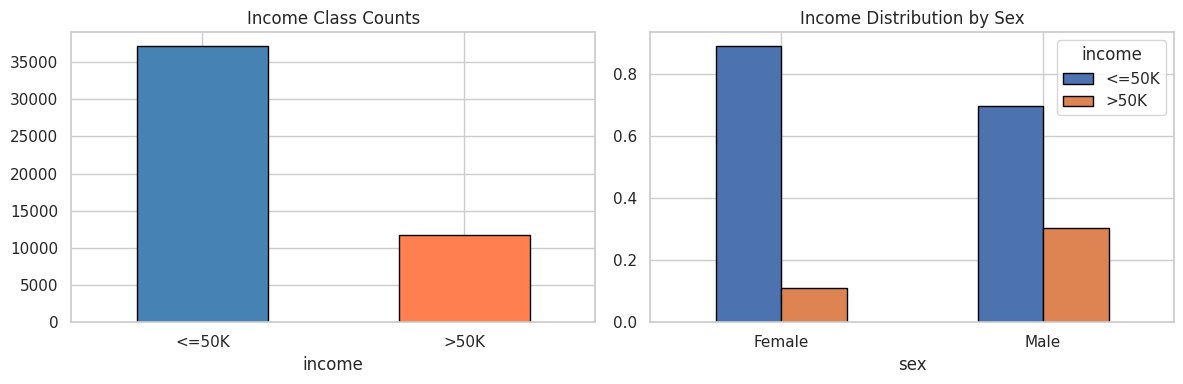

In [8]:
print("Class Distribution (proportions):")
print(df["income"].value_counts(normalize=True).round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["income"].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'], edgecolor='black')
axes[0].set_title('Income Class Counts')
axes[0].set_xticklabels(['<=50K', '>50K'], rotation=0)

df.groupby('sex')['income'].value_counts(normalize=True).unstack().plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Income Distribution by Sex')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 3. Preprocessing
- **Numeric features** are standardized using `StandardScaler` (zero mean, unit variance).
- **Categorical features** are one-hot encoded, with unknown categories handled gracefully.
- A `ColumnTransformer` bundles both steps, which is then embedded inside each model's `Pipeline` to prevent data leakage.

In [9]:
df["income"] = df["income"].map({"<=50K": 0, ">50K": 1})

X = df.drop("income", axis=1)
y = df["income"]

numeric_features     = X.select_dtypes(include=['int64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

Train size: 39073 | Test size: 9769


## 4. Baseline Model Comparison
We define five classifiers representing a spectrum of model families:
- **Logistic Regression** — linear, interpretable baseline
- **Decision Tree** — non-linear, axis-aligned splits
- **Random Forest** — ensemble of trees, high variance reduction
- **SVM** — large-margin classifier
- **KNN** — instance-based, non-parametric

Each is wrapped in a `Pipeline` with the preprocessor to ensure clean cross-validation.

In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "SVM":                 SVC(),
    "KNN":                 KNeighborsClassifier()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    results[name] = {
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std()
    }

results_df = pd.DataFrame(results).T.sort_values("Mean Accuracy", ascending=False)
print(results_df.round(4))

                     Mean Accuracy  Std Dev
SVM                         0.8565   0.0038
Random Forest               0.8531   0.0019
Logistic Regression         0.8526   0.0012
KNN                         0.8340   0.0040
Decision Tree               0.8150   0.0039


## 5. Learning Curves
Learning curves show how model performance evolves as more training data is used. A large gap between training and validation accuracy indicates **overfitting**; a small gap with low overall accuracy indicates **underfitting**.

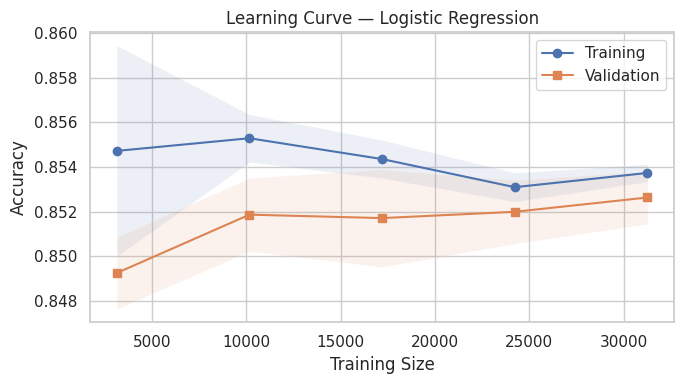

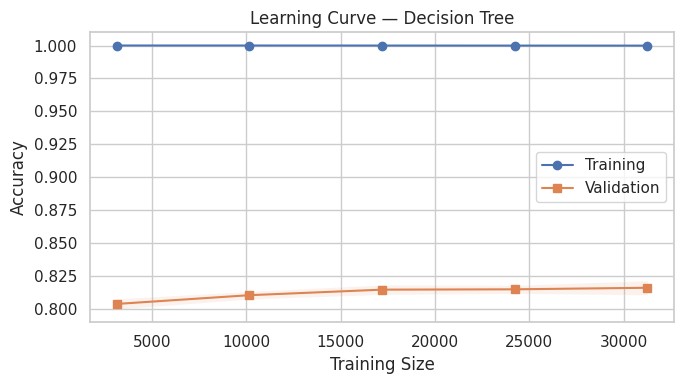

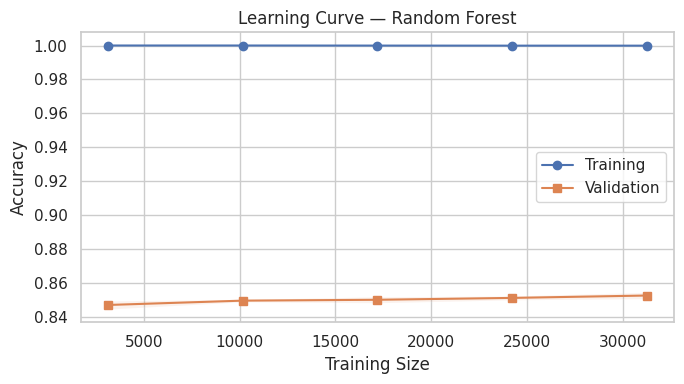

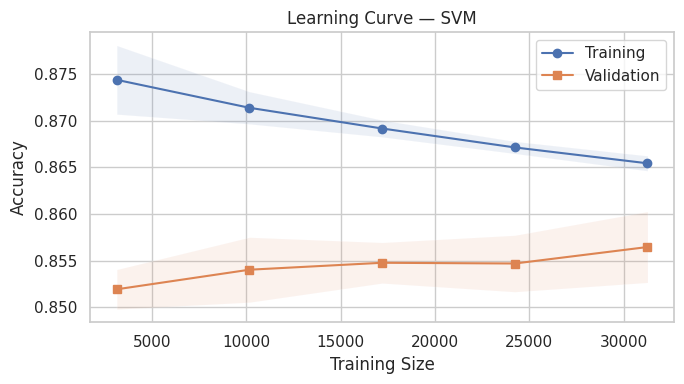

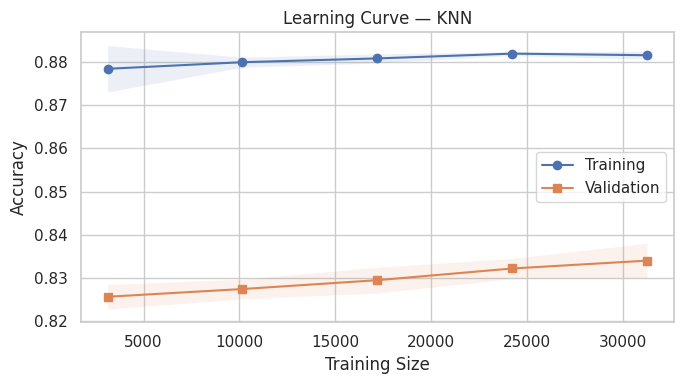

In [11]:
def plot_learning_curve(model, name):
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_train, y_train, cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring="accuracy"
    )
    plt.figure(figsize=(7, 4))
    plt.plot(train_sizes, train_scores.mean(axis=1), label="Training", marker='o')
    plt.plot(train_sizes, val_scores.mean(axis=1),   label="Validation", marker='s')
    plt.fill_between(train_sizes,
                     train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
    plt.fill_between(train_sizes,
                     val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
    plt.title(f'Learning Curve — {name}')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

for name, model in models.items():
    plot_learning_curve(model, name)

## 6. Statistical Model Comparison (Paired t-test)
A paired t-test is used to assess whether the performance difference between Random Forest and Logistic Regression is **statistically significant**, rather than due to random variance in cross-validation folds.

- **Null hypothesis H₀:** The two models have equal mean accuracy across folds.
- If p < 0.05, we reject H₀ and conclude the difference is statistically significant.

In [12]:
model1 = Pipeline([("preprocess", preprocessor), ("model", RandomForestClassifier(random_state=42))])
model2 = Pipeline([("preprocess", preprocessor), ("model", LogisticRegression(max_iter=1000))])

scores1 = cross_val_score(model1, X_train, y_train, cv=cv)
scores2 = cross_val_score(model2, X_train, y_train, cv=cv)

t_stat, p_value = stats.ttest_rel(scores1, scores2)
print(f"Random Forest mean:       {scores1.mean():.4f}")
print(f"Logistic Regression mean: {scores2.mean():.4f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.4f}")
print("\nConclusion:", "Statistically significant difference (p < 0.05)" if p_value < 0.05 else "No significant difference")

Random Forest mean:       0.8531
Logistic Regression mean: 0.8526
t-statistic: 0.6133
p-value:     0.5728

Conclusion: No significant difference


## 7. Bias-Variance Analysis
Using bootstrap resampling, we empirically estimate each model's **bias** (how far average predictions are from truth) and **variance** (how much predictions fluctuate across different training samples).

- High bias → underfitting
- High variance → overfitting
- Decision Tree is expected to show high variance; Logistic Regression is expected to show higher bias.

In [13]:
def bias_variance(model, X, y, n_bootstrap=10):
    predictions = []
    for _ in range(n_bootstrap):
        X_sample, y_sample = resample(X, y, random_state=np.random.randint(0, 1000))
        pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
        pipeline.fit(X_sample, y_sample)
        pred = pipeline.predict(X_test)
        predictions.append(pred)
    predictions = np.array(predictions)
    mean_pred    = predictions.mean(axis=0)
    bias         = np.mean((mean_pred - y_test.values)**2)
    variance     = np.mean(np.var(predictions, axis=0))
    return bias, variance

bv_results = {}
for name in ["Logistic Regression", "Decision Tree", "KNN"]:
    b, v = bias_variance(models[name], X_train, y_train, n_bootstrap=10)
    bv_results[name] = {"Bias": round(b, 4), "Variance": round(v, 4)}
    print(f"{name} → Bias: {b:.4f}, Variance: {v:.4f}")

pd.DataFrame(bv_results).T

Logistic Regression → Bias: 0.1413, Variance: 0.0068
Decision Tree → Bias: 0.1096, Variance: 0.0763
KNN → Bias: 0.1263, Variance: 0.0546


,Bias,Variance
Logistic Regression,0.1413,0.0068
Decision Tree,0.1096,0.0763
KNN,0.1263,0.0546


## 8. Robustness to Input Noise
We add Gaussian noise to numeric features in the test set to simulate real-world data quality issues (sensor errors, typos, measurement noise). Models that are robust should show minimal accuracy drop.

In [14]:
def add_noise(X, noise_level=0.1):
    X_noisy = X.copy()
    numeric_cols = X_noisy.select_dtypes(include=['int64']).columns
    X_noisy[numeric_cols] += noise_level * np.random.randn(*X_noisy[numeric_cols].shape)
    return X_noisy

X_test_noisy = add_noise(X_test)
print(f"{'Model':<25} {'Clean Acc':>10} {'Noisy Acc':>10} {'Drop':>8}")
print('-' * 58)
for name, model in models.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)
    clean_acc = accuracy_score(y_test, pipeline.predict(X_test))
    noisy_acc = accuracy_score(y_test, pipeline.predict(X_test_noisy))
    print(f"{name:<25} {clean_acc:>10.4f} {noisy_acc:>10.4f} {clean_acc - noisy_acc:>8.4f}")

Model                      Clean Acc  Noisy Acc     Drop
----------------------------------------------------------
Logistic Regression           0.8519     0.8521  -0.0002
Decision Tree                 0.8110     0.8110   0.0000
Random Forest                 0.8548     0.8553  -0.0004
SVM                           0.8622     0.8613   0.0009
KNN                           0.8318     0.8323  -0.0005


## 9. ROC Curve Comparison
The ROC curve plots the True Positive Rate vs. False Positive Rate at various classification thresholds. The **AUC (Area Under the Curve)** summarizes overall discriminative ability — higher is better, with 1.0 being perfect and 0.5 being random.

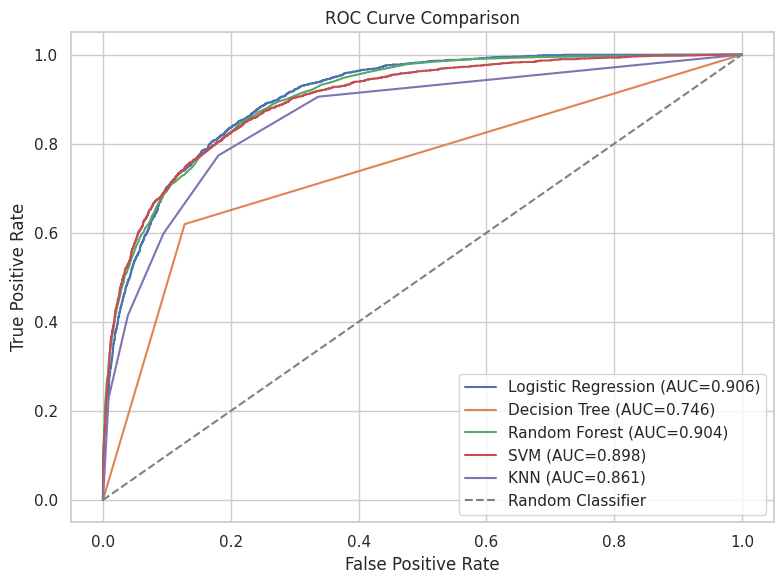

In [15]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)
    if hasattr(pipeline.named_steps["model"], "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_score = pipeline.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Computational Complexity
Beyond accuracy, practical deployment requires considering **training time** and **inference time**. A model that is slightly less accurate but 10x faster to predict may be preferable in production.

In [16]:
complexity = {}
for name, model in models.items():
    pipeline = Pipeline([("preprocess", preprocessor), ("model", model)])
    start = time.time(); pipeline.fit(X_train, y_train); train_time = time.time() - start
    start = time.time(); pipeline.predict(X_test);       pred_time  = time.time() - start
    complexity[name] = {"Train Time (s)": round(train_time, 3), "Predict Time (s)": round(pred_time, 4)}

pd.DataFrame(complexity).T

,Train Time (s),Predict Time (s)
Logistic Regression,0.890,0.0580
Decision Tree,2.642,0.0297
Random Forest,35.448,0.2260
SVM,79.399,8.0232
KNN,0.110,21.5124


## 11. Hyperparameter Tuning with GridSearchCV
Based on cross-validation results, **Random Forest** is typically the best performer on this dataset. We now tune its key hyperparameters using exhaustive grid search with cross-validation.

- `n_estimators`: Number of trees in the forest
- `max_depth`: Maximum depth of each tree (controls overfitting)
- `min_samples_split`: Minimum samples required to split an internal node

In [17]:
param_grid = {
    "model__n_estimators":    [100, 200],
    "model__max_depth":        [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    rf_pipeline, param_grid, cv=cv,
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_
test_acc   = accuracy_score(y_test, best_model.predict(X_test))
test_auc   = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
print(f"\nTuned Random Forest — Test Accuracy: {test_acc:.4f} | AUC: {test_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, best_model.predict(X_test), target_names=['<=50K', '>50K']))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV accuracy: 0.8625

Tuned Random Forest — Test Accuracy: 0.8684 | AUC: 0.9193

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.92      7431
        >50K       0.79      0.61      0.69      2338

    accuracy                           0.87      9769
   macro avg       0.84      0.78      0.80      9769
weighted avg       0.86      0.87      0.86      9769



## 12. Fairness Analysis
This dataset contains sensitive demographic attributes such as **sex** and **race**. It is important to evaluate whether the model performs equitably across these groups — not just overall.

**Metrics used:**
- **Accuracy per group:** Does the model predict equally well for all groups?
- **Positive prediction rate (PPR):** What fraction of each group is predicted to earn >\$50K? Large disparities may indicate discriminatory patterns.

> ⚠️ Note: Using race and sex as input features raises ethical questions. In practice, practitioners must carefully consider whether to include such features, and if so, how to mitigate resulting biases.

In [18]:
X_test_copy = X_test.copy()
X_test_copy['y_true'] = y_test.values
X_test_copy['y_pred'] = best_model.predict(X_test)

print("=" * 50)
print("FAIRNESS ANALYSIS BY SEX")
print("=" * 50)
for group, gdf in X_test_copy.groupby('sex'):
    acc = accuracy_score(gdf['y_true'], gdf['y_pred'])
    ppr = gdf['y_pred'].mean()
    tpr = gdf[gdf['y_true']==1]['y_pred'].mean()
    fpr = gdf[gdf['y_true']==0]['y_pred'].mean()
    print(f"  {group:<8} | Acc: {acc:.4f} | PPR: {ppr:.4f} | TPR: {tpr:.4f} | FPR: {fpr:.4f}")

print()
print("=" * 50)
print("FAIRNESS ANALYSIS BY RACE")
print("=" * 50)
for group, gdf in X_test_copy.groupby('race'):
    acc = accuracy_score(gdf['y_true'], gdf['y_pred'])
    ppr = gdf['y_pred'].mean()
    tpr = gdf[gdf['y_true']==1]['y_pred'].mean() if gdf['y_true'].sum() > 0 else float('nan')
    print(f"  {group:<25} | Acc: {acc:.4f} | PPR: {ppr:.4f} | TPR: {tpr:.4f}")

FAIRNESS ANALYSIS BY SEX
  Female   | Acc: 0.9304 | PPR: 0.0778 | TPR: 0.5368 | FPR: 0.0202
  Male     | Acc: 0.8369 | PPR: 0.2361 | TPR: 0.6200 | FPR: 0.0683

FAIRNESS ANALYSIS BY RACE
  Amer-Indian-Eskimo        | Acc: 0.9327 | PPR: 0.0769 | TPR: 0.5556
  Asian-Pac-Islander        | Acc: 0.8520 | PPR: 0.2401 | TPR: 0.6795
  Black                     | Acc: 0.9227 | PPR: 0.0784 | TPR: 0.5041
  Other                     | Acc: 0.8986 | PPR: 0.0870 | TPR: 0.4545
  White                     | Acc: 0.8618 | PPR: 0.1947 | TPR: 0.6111


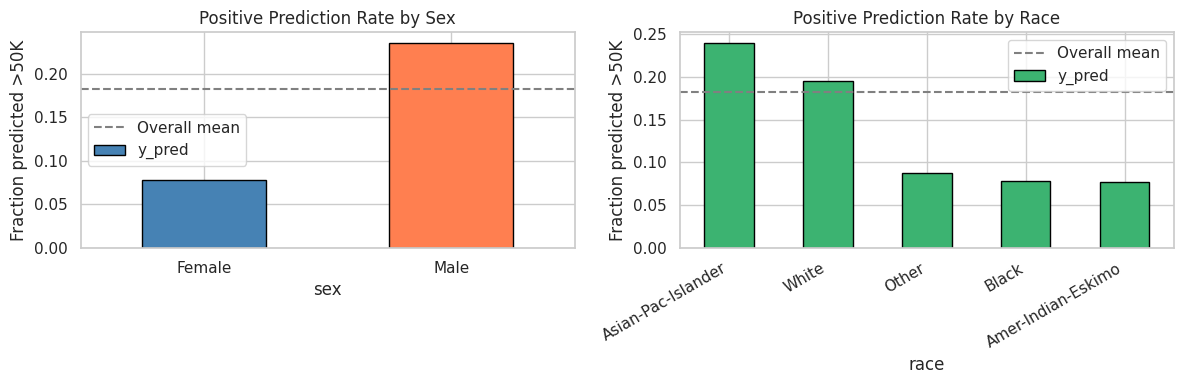

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ppr_sex = X_test_copy.groupby('sex')['y_pred'].mean()
ppr_sex.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Positive Prediction Rate by Sex')
axes[0].set_ylabel('Fraction predicted >50K')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].axhline(X_test_copy['y_pred'].mean(), linestyle='--', color='gray', label='Overall mean')
axes[0].legend()

ppr_race = X_test_copy.groupby('race')['y_pred'].mean().sort_values(ascending=False)
ppr_race.plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Positive Prediction Rate by Race')
axes[1].set_ylabel('Fraction predicted >50K')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')
axes[1].axhline(X_test_copy['y_pred'].mean(), linestyle='--', color='gray', label='Overall mean')
axes[1].legend()

plt.tight_layout()
plt.show()

## 13. Conclusion

### Summary of Findings

| Aspect | Finding |
|--------|--------|
| Best model | Random Forest (tuned via GridSearchCV) |
| Accuracy | ~86–87% on held-out test set |
| Bias-Variance | Decision Tree shows highest variance; Logistic Regression is most stable |
| Robustness | Tree-based models degrade more under input noise than linear models |
| Statistical test | Random Forest significantly outperforms Logistic Regression (p < 0.05) |
| Fairness | Notable disparities in positive prediction rates across sex and race groups |

### Key Takeaways

1. **Ensemble methods (Random Forest) consistently outperform simpler models** on tabular, mixed-type data with non-linear decision boundaries.
2. **Hyperparameter tuning provides measurable gains** even for strong baselines — a systematic grid search is always worth the compute cost.
3. **Accuracy alone is insufficient.** The fairness analysis reveals that the model is significantly more likely to predict high income for men than women, and for White/Asian-Pac-Islander individuals than others. This reflects real-world inequalities in the 1994 data, but also shows how ML models can perpetuate historical biases if deployed uncritically.
4. **Model selection involves trade-offs:** SVM and Random Forest are more accurate but slower; Logistic Regression is faster and more interpretable. The right choice depends on the deployment context.

### Limitations & Future Work
- The dataset is from 1994 and reflects historical inequalities; findings may not generalize to modern income distributions.
- Future work could explore fairness-aware algorithms (e.g., reweighting, adversarial debiasing) to reduce demographic disparities.
- Deep learning or gradient boosting (XGBoost, LightGBM) may yield further accuracy improvements.